<a href="https://colab.research.google.com/github/solomon7-data/Athlete/blob/main/Phase_3%3A%20Correlation_Analysis_Athlete_real_world_data_set.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [3]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

what to do wth this data
- [] check number of Athelet by country and sex
- [] kvksgkj
- [] kvksgkj
- [] kvksgkj
- [] kvksgkj


In [4]:
url = "https://github.com/solomon7-data/Athlete/raw/main/df_KNNI.csv.zip"

df = pd.read_csv(url, compression="zip")

df.head()

,roles,sex,full_name,height_cm,weight_kg,born_date,date_died,age_at_death,city,region,country
0,Competed in Olympic Games • Other,Female,Hend•Zaza,176.333724,72.006257,2009-01-01,NaN,NaN,Hama,Hama,SYR
1,Competed in Olympic Games,Female,Kokona•Hiraki,176.333724,72.006257,2008-08-26,NaN,NaN,unknown,unknown,unknown
2,Competed in Olympic Games,Female,Sky•Brown,176.333724,72.006257,2008-07-07,NaN,NaN,Miyazaki,Miyazaki,JPN
3,Competed in Olympic Games,Female,Jhulia Rayssa•Mendes Leal,147.000000,35.000000,2008-01-04,NaN,NaN,Imperatriz,Maranhão,BRA
4,Competed in Olympic Games,Female,Momiji•Nishiya,176.333724,72.006257,2007-08-30,NaN,NaN,unknown,unknown,unknown


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 145500 entries, 0 to 145499
Data columns (total 11 columns):
 #   Column        Non-Null Count   Dtype  
---  ------        --------------   -----  
 0   roles         145500 non-null  object 
 1   sex           145500 non-null  object 
 2   full_name     145500 non-null  object 
 3   height_cm     145500 non-null  float64
 4   weight_kg     145500 non-null  float64
 5   born_date     143698 non-null  object 
 6   date_died     33963 non-null   object 
 7   age_at_death  33872 non-null   float64
 8   city          145500 non-null  object 
 9   region        145500 non-null  object 
 10  country       145500 non-null  object 
dtypes: float64(3), object(8)
memory usage: 12.2+ MB


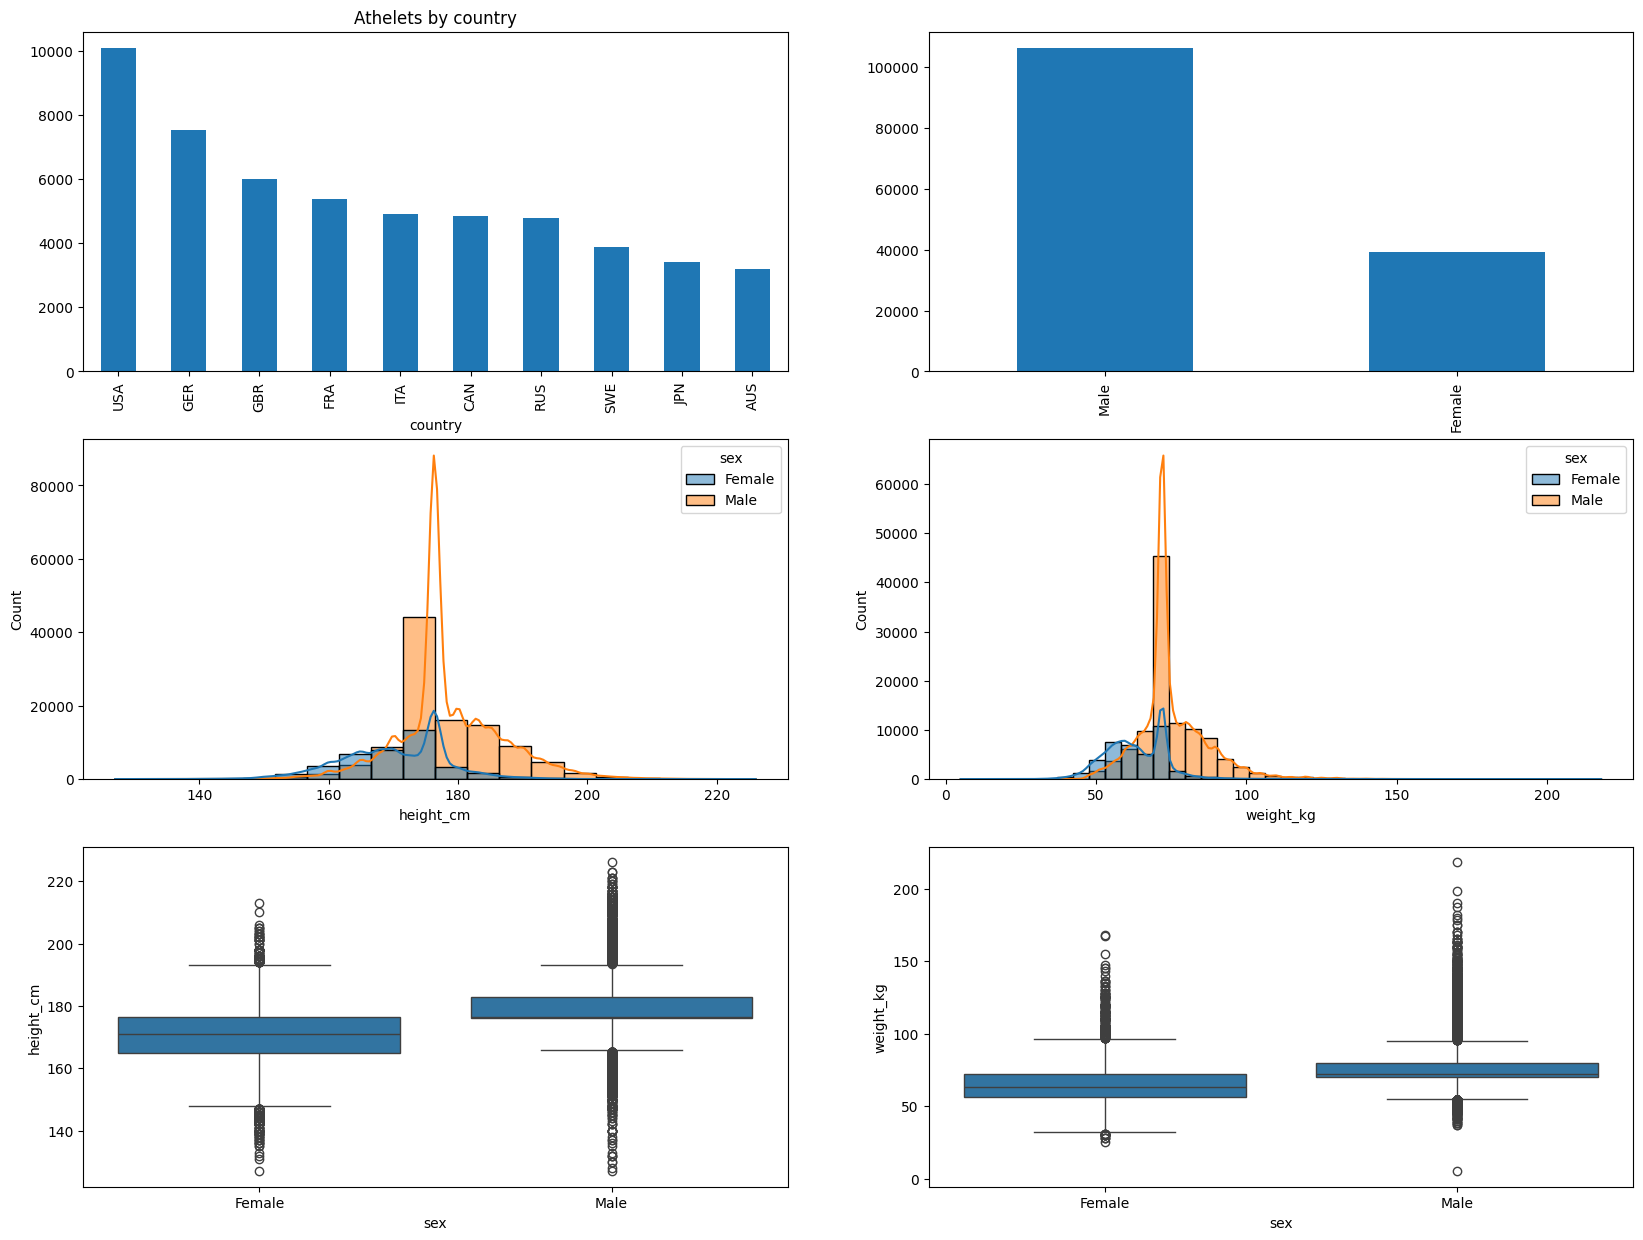

In [29]:
fig, axes = plt.subplots(3,2, figsize=(20,15))

df.groupby("country")['country'].value_counts().sort_values(ascending=False).iloc[1:11].head(20).plot(kind="bar",ax = axes[0,0])
axes[0,0].set_title('Athelets by country')

df.groupby("sex")['sex'].value_counts().sort_values(ascending=False).head(10).plot(kind="bar",ax = axes[0,1])
axes[0, 1].set_xlabel('Sex')
axes[0,1].tick_params(axis='x', rotation=45)
df.groupby("sex")['sex'].value_counts().sort_values(ascending=False).head(10).plot(kind="bar",ax = axes[0,1])

sns.boxplot(data=df, x="sex", y="height_cm", ax = axes[2,0])
sns.boxplot(data=df, x="sex", y="weight_kg", ax = axes[2,1])

sns.histplot(data=df, x="height_cm", hue="sex", kde=True,ax = axes[1,0],bins=20)
sns.histplot(data=df, x="weight_kg", hue="sex", kde=True,ax = axes[1,1],bins=40)
plt.show()


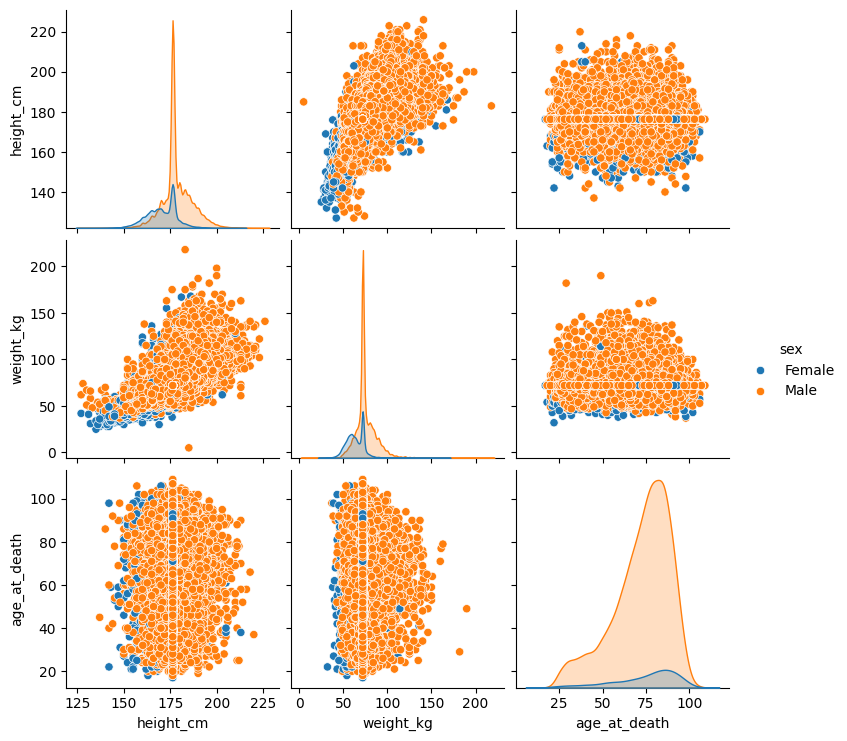

In [16]:
sns.pairplot(data=df, hue="sex")

In [34]:
df[["height_cm", "weight_kg"]].corr(method="pearson").round(2)

,height_cm,weight_kg
height_cm,1.00,0.78
weight_kg,0.78,1.00


In [36]:
df[["height_cm", "weight_kg"]].corr(method="spearman").round(2)

,height_cm,weight_kg
height_cm,1.00,0.79
weight_kg,0.79,1.00


In [37]:
from scipy.stats import pearsonr

temp = df[["height_cm", "weight_kg"]].dropna()

r, p = pearsonr(
    temp["height_cm"],
    temp["weight_kg"]
)

print("Pearson r:", r)
print("p-value:", p)

Pearson r: 0.7802669753908624
p-value: 0.0


In [38]:
df["age_at_death"].describe()

,age_at_death
count,33872.000000
mean,72.459199
std,16.733320
min,17.000000
25%,63.000000
50%,76.000000
75%,85.000000
max,109.000000


<Axes: xlabel='age_at_death', ylabel='Count'>

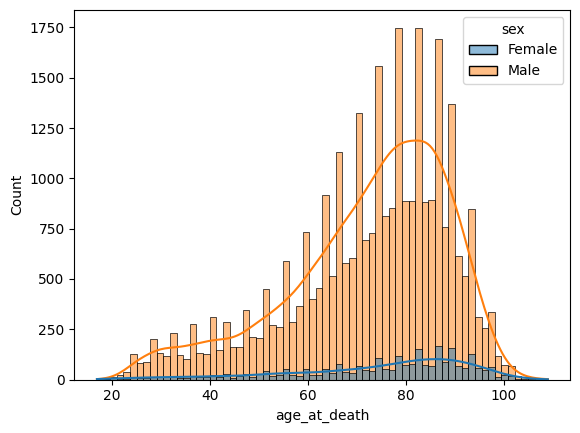

In [41]:
sns.histplot(
    data=df,
    x="age_at_death",
    kde=True,hue="sex"
)